In [ ]:
from pathlib import Path

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


PLOT_TYPE = "paper"
# we can use "talk" for slides, "paper" for our report. Set it here rather than per figure.
#sns.set_theme(style="whitegrid", context="paper")
plt.rcParams["figure.figsize"] = (6.5, 4)

ANALYSIS = Path(".")          # this notebook lives in analysis
E1, E2 = ANALYSIS / "experiment-1", ANALYSIS / "experiment-2"


In [ ]:
def savefig(obj,path,name):
    """Save either a seaborn Axes or FacetGrid."""
    fig = obj.figure
    fig.savefig(f"{path}/{name}.pdf", bbox_inches="tight")

In [ ]:
def load(directory):
    runs = pd.read_csv(directory / "runs.csv")
    rounds = pd.read_csv(directory / "rounds.csv")
    # rounds.csv names the config but not the adversary count
    rounds = rounds.merge(runs[["run_id", "adversarial", "honest"]], on="run_id")
    return runs, rounds

e1_runs, e1_rounds = load(E1)
e2_runs, e2_rounds = load(E2)

# the question is damage to honest peers, so we drop the adversaries own models
e1_honest = e1_rounds[e1_rounds.node_type == "normal"]
e2_honest = e2_rounds[e2_rounds.node_type == "normal"]

# categorical, or seaborn treats the hue as continuous and the legend
# silently lists only a sample of the adversary counts
e1_honest = e1_honest.assign(adversaries=e1_honest["adversarial"].astype("category"))

LAST = e1_rounds["round"].max()

## Experiment 1 
10 peers one averaging group of size 10

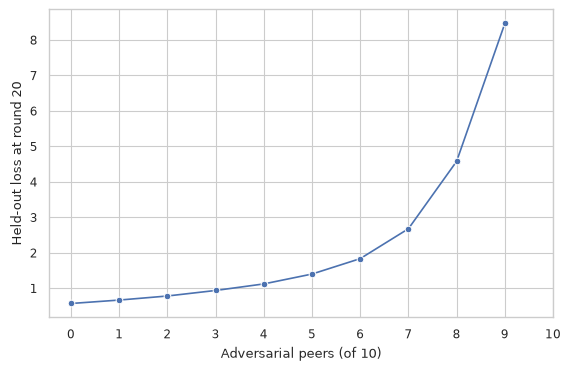

In [ ]:
ax = sns.lineplot(data=e1_runs, x="adversarial", y="honest_eval_loss", marker="o")
ax.set(xlabel="Adversarial peers (of 10)", ylabel=f"Held-out loss at round {LAST}")
ax.set_xticks(range(0, 11))
if PLOT_TYPE == "paper":
    savefig(ax,path=f"{ANALYSIS}/experiment-1/paper",name="fig-1")
else:
    savefig(ax,path=f"{ANALYSIS}/experiment-1/talk",name="fig-1")

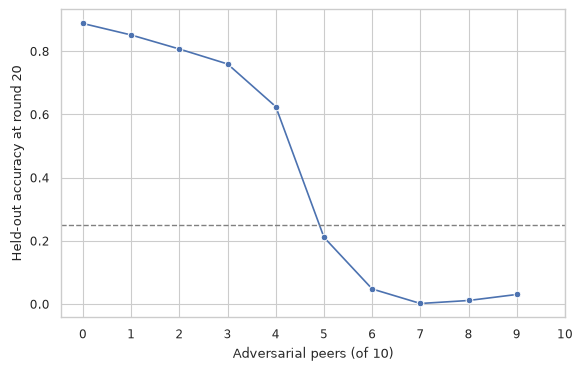

In [4]:
ax = sns.lineplot(data=e1_runs, x="adversarial", y="honest_eval_accuracy", marker="o")
ax.axhline(0.25, ls="--", c="grey", lw=1)
ax.set(xlabel="Adversarial peers (of 10)", ylabel=f"Held-out accuracy at round {LAST}")
ax.set_xticks(range(0, 11))

Every cell starts from the same model, so the curves fan out from one point. All ten
peers average together each round and therefore hold identical weights, so one line
per cell is ... 

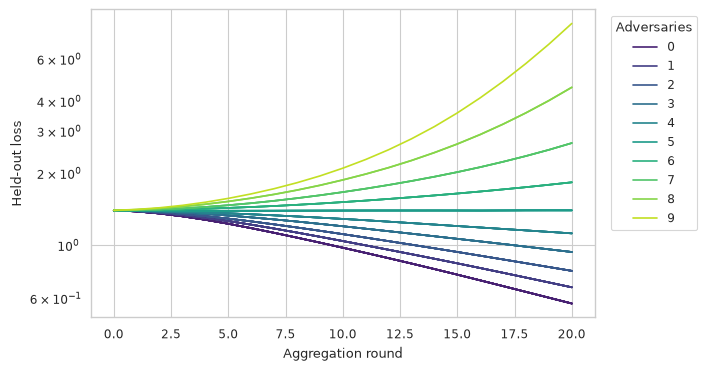

In [5]:
ax = sns.lineplot(data=e1_honest, x="round", y="eval_loss", hue="adversaries",
                  palette="viridis", units="node_id", estimator=None)

ax.set_yscale("log") ## set to log so it easier to read 
ax.set(xlabel="Aggregation round", ylabel="Held-out loss")
ax.legend(title="Adversaries", bbox_to_anchor=(1.02, 1), loc="upper left")

The dashed line is 0.25, the class prior. Below it the model is being driven actively wrong, not merely failing to learn.

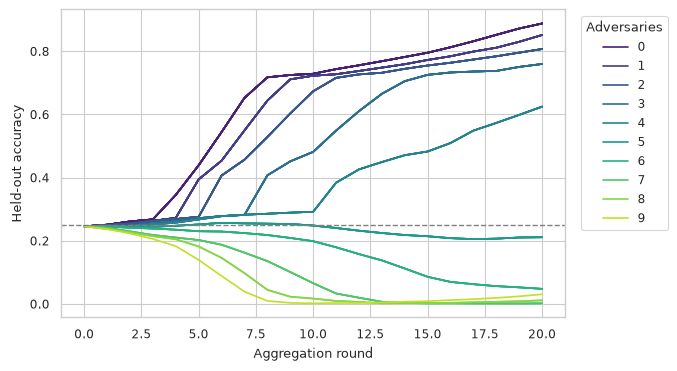

In [6]:
ax = sns.lineplot(data=e1_honest, x="round", y="eval_accuracy", hue="adversaries",
                  palette="viridis", units="node_id", estimator=None)
ax.axhline(0.25, ls="--", c="grey", lw=1)
ax.set(xlabel="Aggregation round", ylabel="Held-out accuracy")
ax.legend(title="Adversaries", bbox_to_anchor=(1.02, 1), loc="upper left")

`max_class_fraction` is the largest share of predictions on any one class — still
experiment 1. Near 0.25 the predictions are spread across the four quadrants, near
1.0 the model has collapsed onto a single answer. Read beside accuracy it separates
"learned nothing" from "collapsed" from "driven wrong".

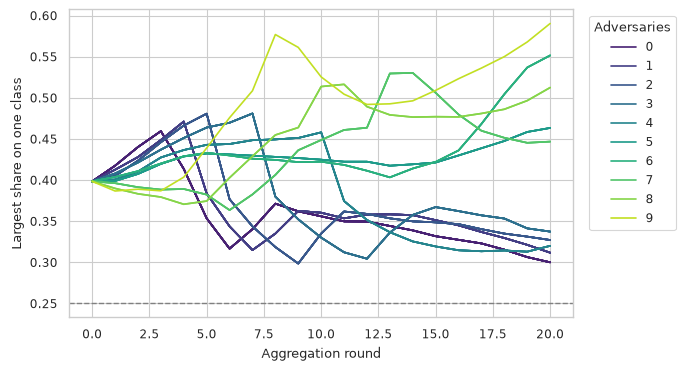

In [7]:
ax = sns.lineplot(data=e1_honest, x="round", y="max_class_fraction", hue="adversaries",
                  palette="viridis", units="node_id", estimator=None)
ax.axhline(0.25, ls="--", c="grey", lw=1)
ax.set(xlabel="Aggregation round", ylabel="Largest share on one class")
ax.legend(title="Adversaries", bbox_to_anchor=(1.02, 1), loc="upper left")

## Experiment 2: 
Peers average in group of 5 out of 10, so they no longer all share one model.
each line is one honest peer. Where line sit exactly on top of each other those peers repetedly average together and coverged.


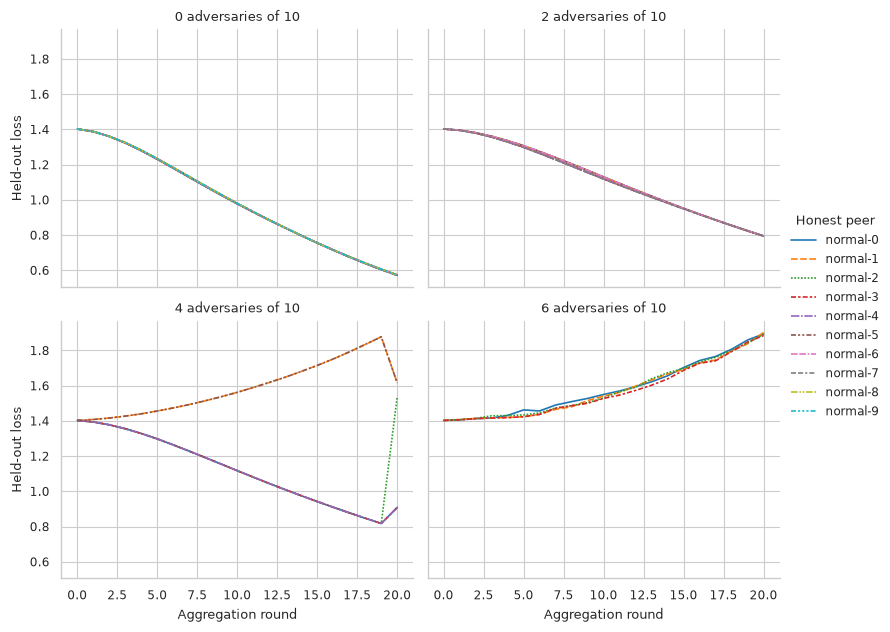

In [8]:
g = sns.relplot(
    data=e2_honest, x="round", y="eval_loss",
    col="adversarial", col_wrap=2,
    kind="line", units="node_id", estimator=None,
    hue="node_id", style="node_id", dashes=True, palette="tab10",
    height=3.2, aspect=1.25,
)
g.set_axis_labels("Aggregation round", "Held-out loss")
g.set_titles("{col_name} adversaries of 10")
g.legend.set_title("Honest peer")

The same data  as above just we are only looking at the  final round.the clearest view of the split. At four adversaries the honest peers separate into two clusters rather than degrading evenly.

[Text(0.5, 0, 'Adversarial peers (of 10)'),
 Text(0, 0.5, 'Held-out loss at round 20')]

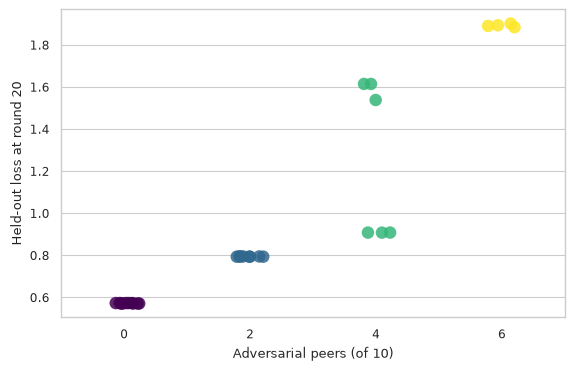

In [9]:
e2_final = e2_honest[e2_honest["round"] == e2_honest["round"].max()]

ax = sns.stripplot(data=e2_final, x="adversarial", y="eval_loss",
                   hue="adversarial", palette="viridis", legend=False,
                   jitter=0.12, size=9, alpha=0.85)
ax.set(xlabel="Adversarial peers (of 10)", ylabel=f"Held-out loss at round {LAST}")